# Stage Directions in German Drama (1510–2010)
### Frequency, Verbosity, Text Length, and Historical Change

This notebook investigates three core questions using a corpus of 746 TEI-encoded German plays:

1. **How does stage direction *frequency* relate to pure text length?**
2. **How do stage direction frequency and verbosity change over publication year?**
3. **Are these relationships statistically significant?**

**Key metrics in the dataset:**
| Column | Meaning |
|---|---|
| `stage_count` | Number of `<stage>` elements |
| `stage_word_count` | Total words inside all stage directions |
| `stage_avg_words` | Mean words per stage direction |
| `word_count_l_p` | Words in `<l>` and `<p>` (pure dramatic text) |
| `stage_per_1k_words` | Stage directions per 1,000 text words (**frequency density**) |
| `stage_words_per_1k` | Stage direction words per 1,000 text words (**verbosity density**) |

## 1. Setup & Data Upload

In [1]:
!pip install -q scipy statsmodels seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr, kruskal, mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from google.colab import files

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})
sns.set_palette('muted')
print('Libraries loaded.')

Libraries loaded.


In [3]:
uploaded = files.upload()   # upload stage_frequency_results.csv
#/content/stage_frequency_results.csv
fname = list(uploaded.keys())[0]
df_raw = pd.read_csv(fname)
print(f'Loaded {len(df_raw)} rows, {df_raw.shape[1]} columns.')
df_raw.head(3)

Saving stage_frequency_results.csv to stage_frequency_results (1).csv
Loaded 731 rows, 10 columns.


,filename,author,title,year,stage_count,stage_word_count,stage_avg_words,word_count_l_p,stage_per_1k_words,stage_words_per_1k
0,achat-ein-april-scherz.xml,NaN,Ein April-Scherz,1842.0,123,406,3.3008,6022,20.4251,67.4195
1,adolph-am-ersten-mai.xml,Adolph,Am ersten Mai,1919.0,156,996,6.3846,6298,24.7698,158.1454
2,alberti-brot.xml,Alberti,Brot!,1888.0,368,1759,4.7799,26475,13.8999,66.4400


## 2. Cleaning & Feature Engineering

In [4]:
df = df_raw.copy()

# Coerce year; drop rows missing key metrics
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year', 'stage_per_1k_words', 'word_count_l_p', 'stage_words_per_1k'])
df['year'] = df['year'].astype(int)

# Remove extreme outliers (|z-score| > 3) in density columns to stabilise plots
for col in ['stage_per_1k_words', 'stage_words_per_1k', 'word_count_l_p']:
    z = np.abs(stats.zscore(df[col]))
    n_before = len(df)
    df = df[z < 3]
    print(f'  {col}: removed {n_before - len(df)} outliers')

# Half-century period bins for group comparisons
bins   = [1699, 1750, 1800, 1850, 1900, 2050]
labels = ['1700–1750', '1751–1800', '1801–1850', '1851–1900', '1901+']
df['period'] = pd.cut(df['year'], bins=bins, labels=labels)
df = df.dropna(subset=['period'])

print(f'\n{len(df)} plays retained after cleaning.')
print('\nPlays per period:')
print(df['period'].value_counts().sort_index())
df[['year','stage_count','stage_avg_words','word_count_l_p',
    'stage_per_1k_words','stage_words_per_1k']].describe().round(2)

  stage_per_1k_words: removed 6 outliers
  stage_words_per_1k: removed 11 outliers
  word_count_l_p: removed 3 outliers

646 plays retained after cleaning.

Plays per period:
period
1700–1750     24
1751–1800    167
1801–1850    210
1851–1900    111
1901+        134
Name: count, dtype: int64


,year,stage_count,stage_avg_words,word_count_l_p,stage_per_1k_words,stage_words_per_1k
count,646.00,646.00,646.00,646.00,646.00,646.00
mean,1837.83,293.35,5.88,13456.28,21.99,133.92
std,55.44,251.44,2.35,8202.02,13.12,100.36
min,1700.00,2.00,1.14,341.00,0.95,2.57
25%,1791.00,99.25,4.30,6257.25,12.22,61.92
50%,1832.00,230.50,5.33,13434.50,19.11,108.99
75%,1893.75,419.50,6.84,19084.75,29.60,179.17
max,2010.00,1890.00,18.40,44030.00,87.19,524.97


## 3. Exploratory Visualisations

### 3.1 Distributions of key metrics

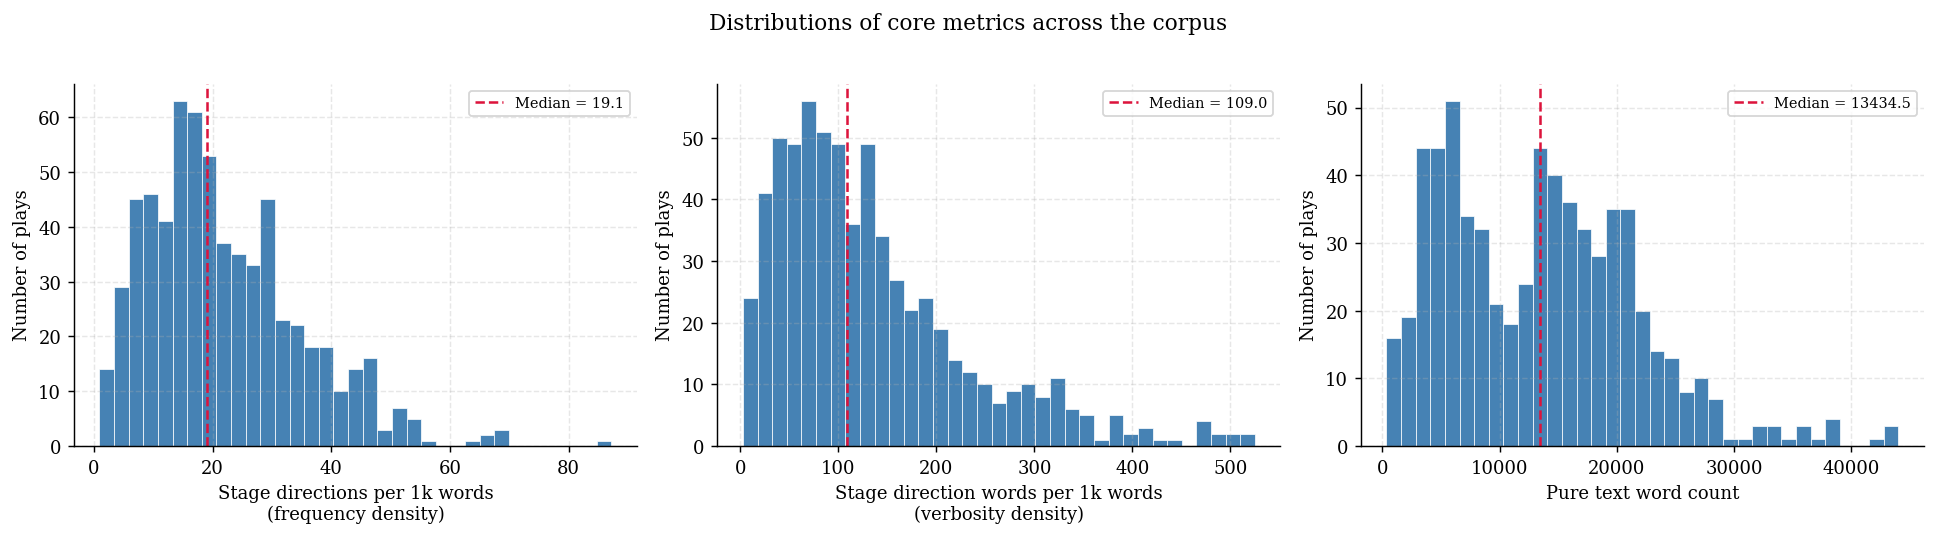

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    ('stage_per_1k_words',  'Stage directions per 1k words\n(frequency density)'),
    ('stage_words_per_1k',  'Stage direction words per 1k words\n(verbosity density)'),
    ('word_count_l_p',      'Pure text word count'),
]
for ax, (col, label) in zip(axes, configs):
    ax.hist(df[col], bins=35, color='steelblue', edgecolor='white', linewidth=0.4)
    med = df[col].median()
    ax.axvline(med, color='crimson', linestyle='--', linewidth=1.4, label=f'Median = {med:.1f}')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Number of plays')
    ax.legend(fontsize=8)

plt.suptitle('Distributions of core metrics across the corpus', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Stage direction metrics over time — scatter + LOWESS trend

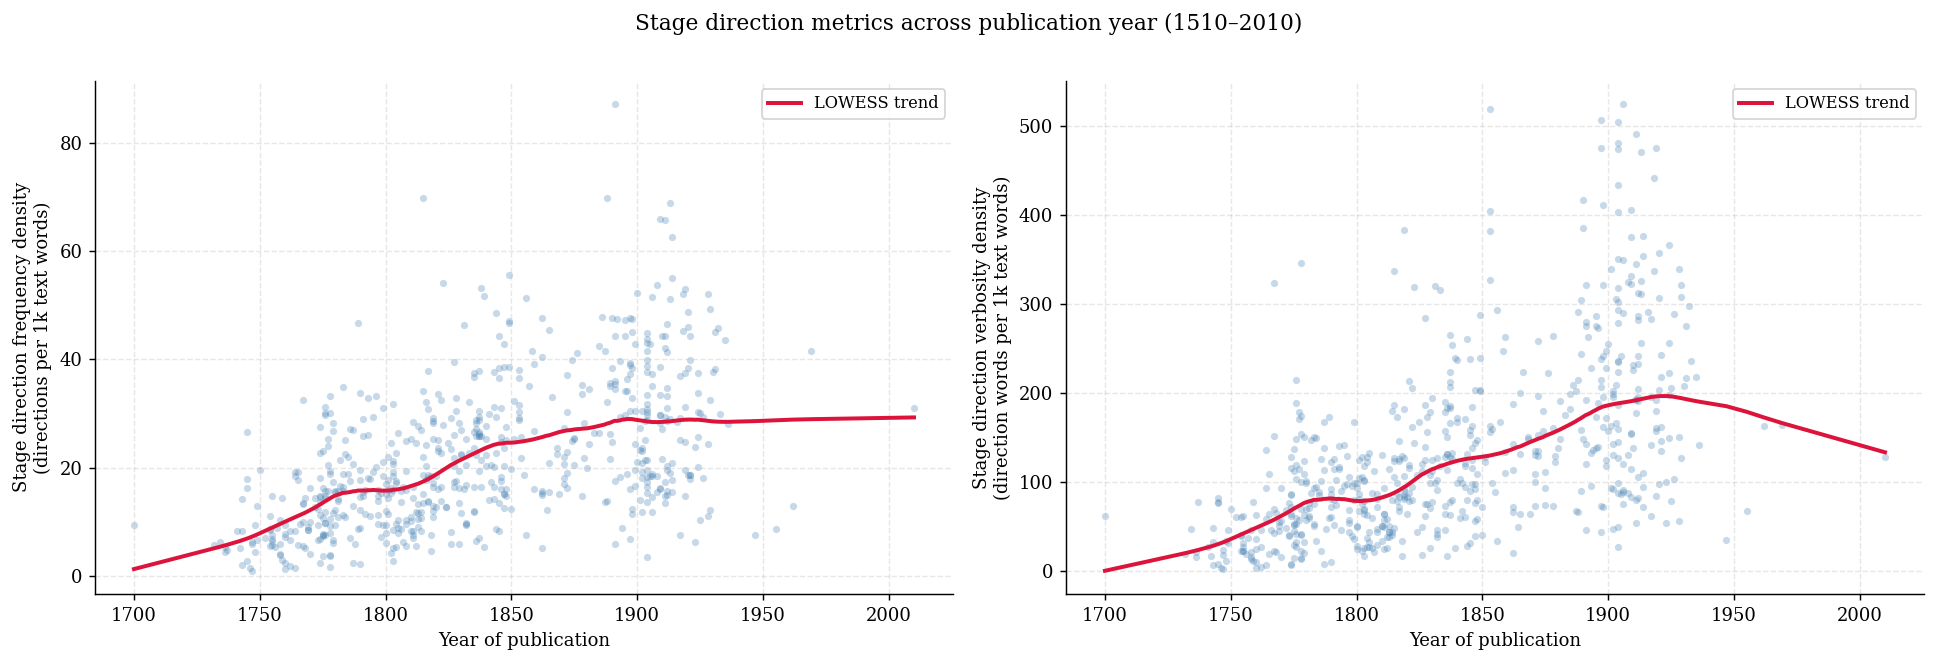

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
configs = [
    ('stage_per_1k_words', 'Stage direction frequency density\n(directions per 1k text words)'),
    ('stage_words_per_1k', 'Stage direction verbosity density\n(direction words per 1k text words)'),
]
for ax, (col, label) in zip(axes, configs):
    ax.scatter(df['year'], df[col], alpha=0.3, s=16, color='steelblue', linewidths=0)
    lowess = sm.nonparametric.lowess(df[col], df['year'], frac=0.3)
    ax.plot(lowess[:, 0], lowess[:, 1], color='crimson', linewidth=2.2, label='LOWESS trend')
    ax.set_xlabel('Year of publication', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Stage direction metrics across publication year (1510–2010)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Text length over time

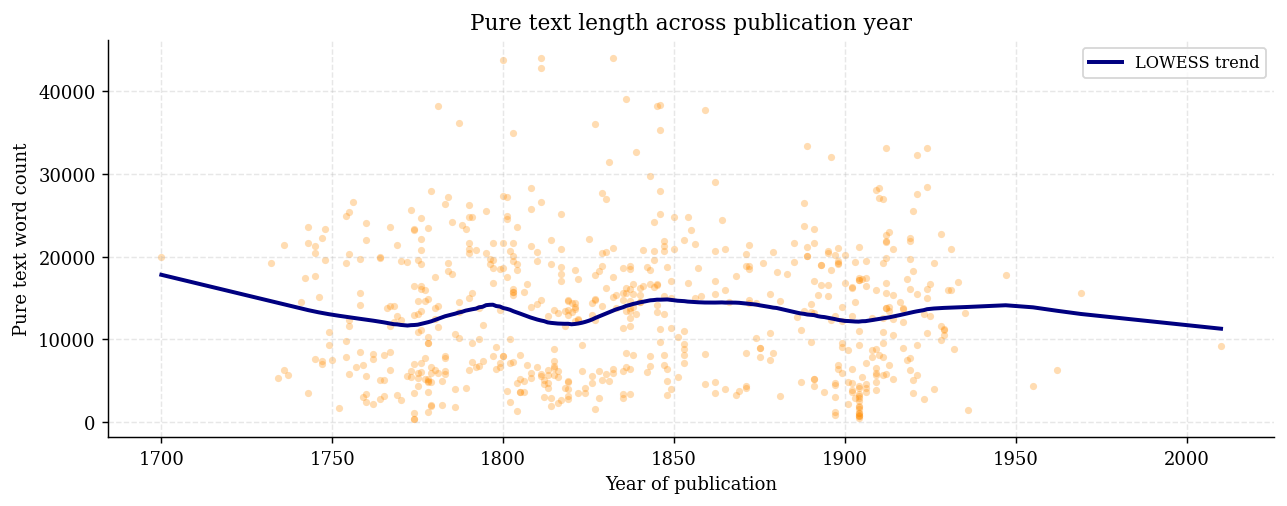

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df['year'], df['word_count_l_p'], alpha=0.3, s=16, color='darkorange', linewidths=0)
lowess = sm.nonparametric.lowess(df['word_count_l_p'], df['year'], frac=0.3)
ax.plot(lowess[:, 0], lowess[:, 1], color='navy', linewidth=2.2, label='LOWESS trend')
ax.set_xlabel('Year of publication', fontsize=10)
ax.set_ylabel('Pure text word count', fontsize=10)
ax.legend(fontsize=9)
ax.set_title('Pure text length across publication year', fontsize=12)
plt.tight_layout()
plt.show()

### 3.4 Boxplots by period — frequency and verbosity

/tmp/ipykernel_12806/3424216987.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='period', y=col, ax=ax, palette=palette,
/tmp/ipykernel_12806/3424216987.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='period', y=col, ax=ax, palette=palette,


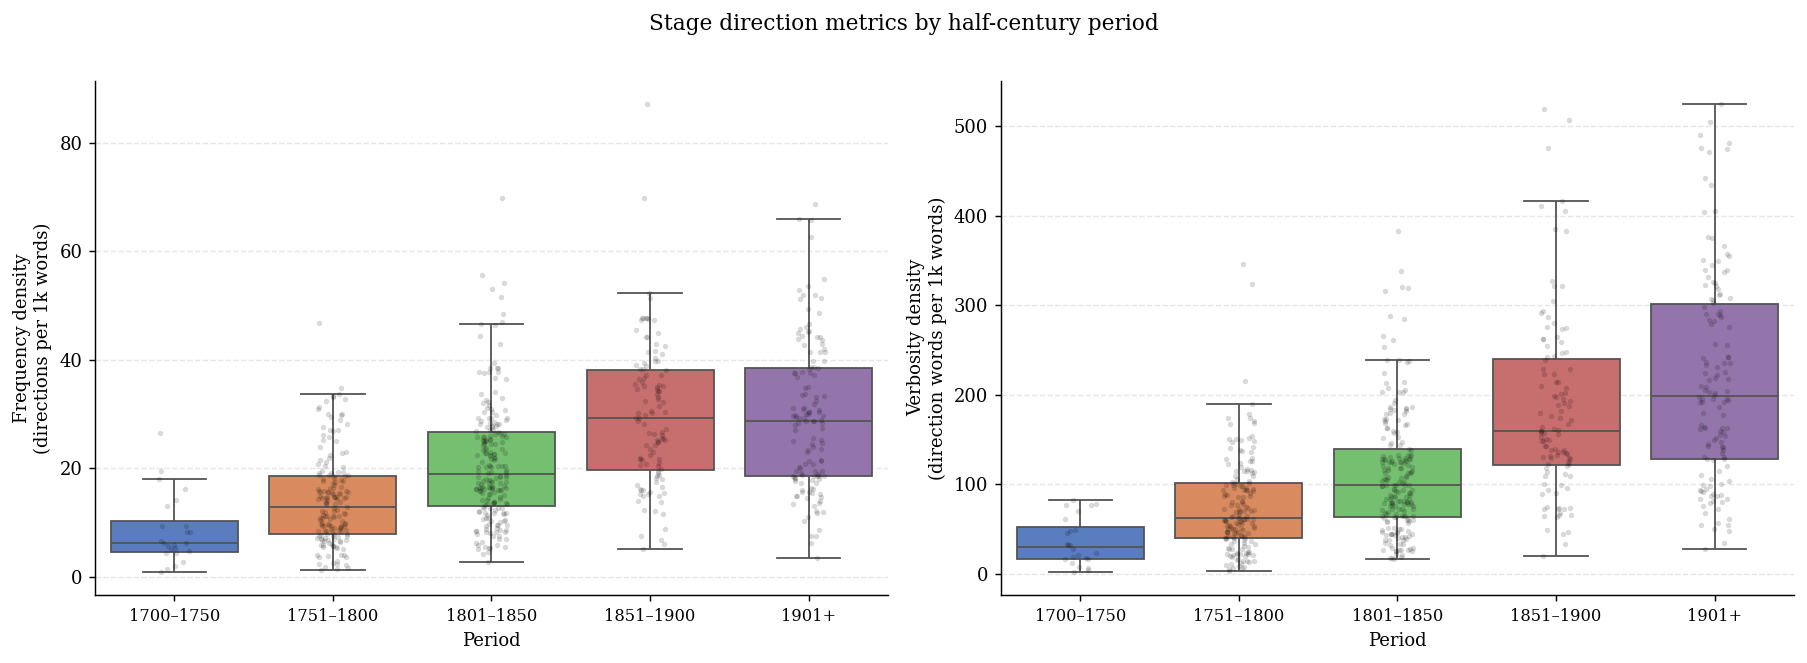

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('muted', n_colors=5)
for ax, col, label in zip(axes,
    ['stage_per_1k_words', 'stage_words_per_1k'],
    ['Frequency density\n(directions per 1k words)',
     'Verbosity density\n(direction words per 1k words)']):
    sns.boxplot(data=df, x='period', y=col, ax=ax, palette=palette,
                order=labels, showfliers=False)
    sns.stripplot(data=df, x='period', y=col, ax=ax, color='black',
                  alpha=0.15, size=3, order=labels, jitter=True)
    ax.set_xlabel('Period', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Stage direction metrics by half-century period', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Stage direction frequency vs. pure text length

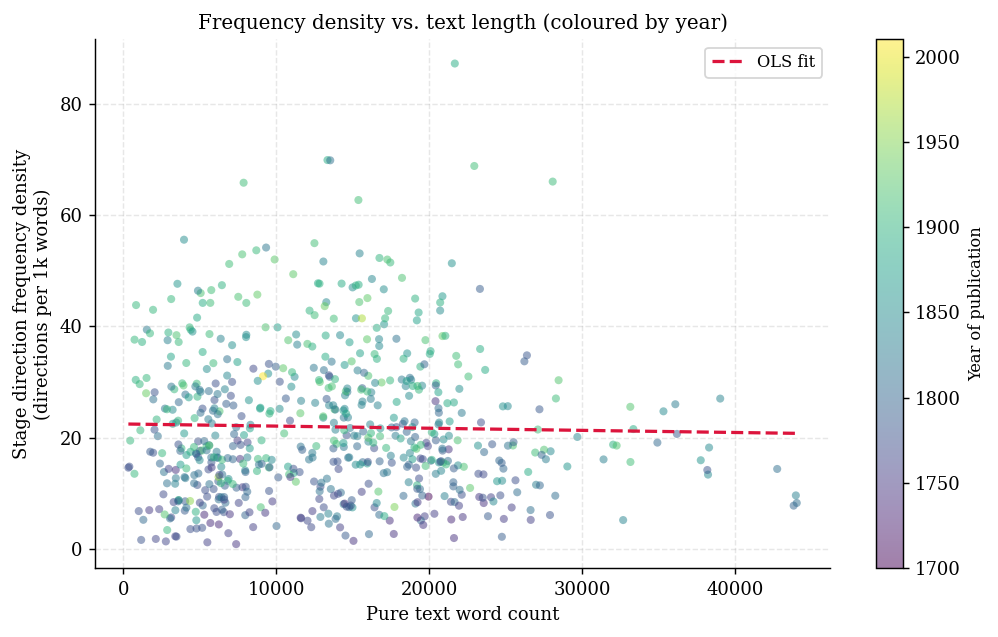

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['word_count_l_p'], df['stage_per_1k_words'],
    c=df['year'], cmap='viridis', alpha=0.5, s=20, linewidths=0
)
cb = plt.colorbar(scatter, ax=ax)
cb.set_label('Year of publication', fontsize=9)
ax.set_xlabel('Pure text word count', fontsize=10)
ax.set_ylabel('Stage direction frequency density\n(directions per 1k words)', fontsize=10)
ax.set_title('Frequency density vs. text length (coloured by year)', fontsize=11)

# OLS regression line
m, b, *_ = stats.linregress(df['word_count_l_p'], df['stage_per_1k_words'])
xr = np.linspace(df['word_count_l_p'].min(), df['word_count_l_p'].max(), 200)
ax.plot(xr, m*xr + b, color='crimson', linewidth=1.8, linestyle='--', label='OLS fit')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

We use **Spearman's rank correlation** throughout because the variables are skewed and the relationships are unlikely to be strictly linear. Pearson r is reported alongside for completeness.

In [10]:
pairs = [
    ('year',          'stage_per_1k_words',  'Year  →  Frequency density'),
    ('year',          'stage_words_per_1k',   'Year  →  Verbosity density'),
    ('year',          'stage_avg_words',       'Year  →  Avg words per direction'),
    ('year',          'word_count_l_p',        'Year  →  Text length'),
    ('word_count_l_p','stage_per_1k_words',   'Text length  →  Frequency density'),
    ('word_count_l_p','stage_words_per_1k',    'Text length  →  Verbosity density'),
    ('stage_per_1k_words','stage_words_per_1k','Frequency density  →  Verbosity density'),
]

rows = []
for x, y, label in pairs:
    rho, p_s = spearmanr(df[x], df[y])
    r,   p_p = pearsonr(df[x], df[y])
    rows.append({'Relationship': label,
                 'Spearman ρ': round(rho, 3),
                 'p (Spearman)': f'{p_s:.2e}',
                 'Pearson r': round(r, 3),
                 'p (Pearson)': f'{p_p:.2e}',
                 'Significant (α=.05)': '✓' if p_s < 0.05 else '✗'})

corr_df = pd.DataFrame(rows)
print(corr_df.to_string(index=False))

                           Relationship  Spearman ρ p (Spearman)  Pearson r p (Pearson) Significant (α=.05)
             Year  →  Frequency density       0.559     1.87e-54      0.528    1.43e-47                   ✓
             Year  →  Verbosity density       0.624     5.22e-71      0.573    1.05e-57                   ✓
       Year  →  Avg words per direction       0.400     2.81e-26      0.357    7.68e-21                   ✓
                   Year  →  Text length       0.009     8.12e-01     -0.003    9.42e-01                   ✗
      Text length  →  Frequency density      -0.002     9.52e-01     -0.024    5.44e-01                   ✗
      Text length  →  Verbosity density      -0.009     8.11e-01     -0.082    3.74e-02                   ✗
Frequency density  →  Verbosity density       0.899    2.32e-233      0.818   7.84e-157                   ✓


### 4.1 Correlation heatmap

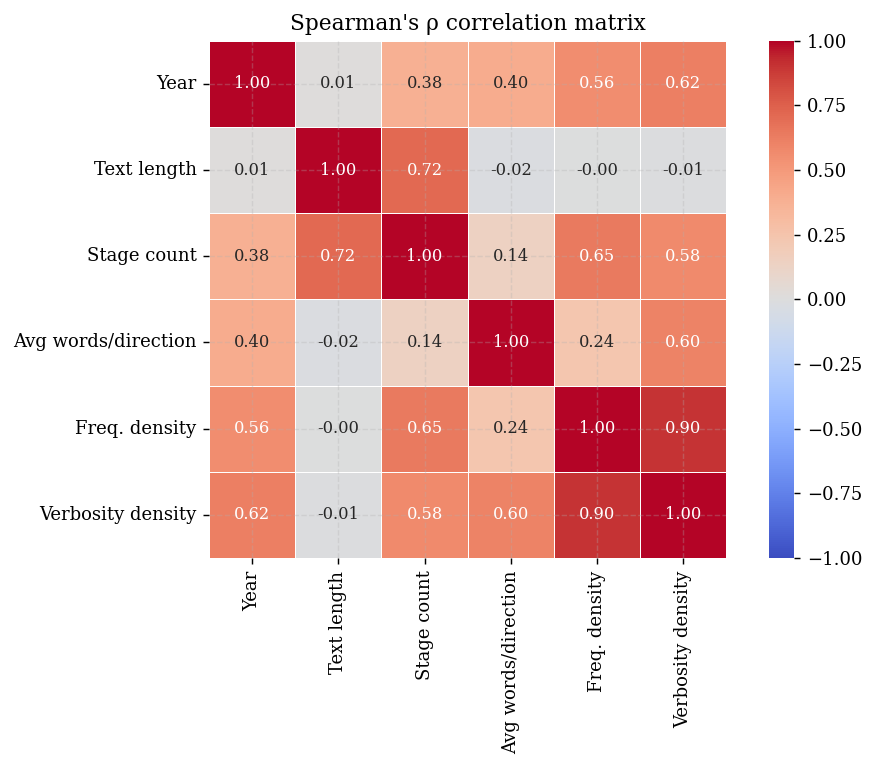

In [11]:
cols_of_interest = ['year', 'word_count_l_p', 'stage_count',
                    'stage_avg_words', 'stage_per_1k_words', 'stage_words_per_1k']
labels_heat = ['Year', 'Text length', 'Stage count',
                'Avg words/direction', 'Freq. density', 'Verbosity density']

rho_matrix = pd.DataFrame(
    [[spearmanr(df[a], df[b])[0] for b in cols_of_interest] for a in cols_of_interest],
    index=labels_heat, columns=labels_heat
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rho_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title("Spearman's ρ correlation matrix", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Statistical Significance Testing by Period

### 5.1 Kruskal-Wallis test
Because the data are non-normally distributed, we use the **Kruskal-Wallis H test** (non-parametric equivalent of one-way ANOVA) to test whether the five half-century periods differ significantly in stage direction frequency and verbosity density.

In [12]:
groups_freq = [df.loc[df['period'] == p, 'stage_per_1k_words'].values for p in labels]
groups_verb = [df.loc[df['period'] == p, 'stage_words_per_1k'].values for p in labels]

H_freq, p_freq = kruskal(*groups_freq)
H_verb, p_verb = kruskal(*groups_verb)

print('Kruskal-Wallis test — stage direction FREQUENCY density across periods:')
print(f'  H = {H_freq:.3f},  p = {p_freq:.2e}  →  {"significant" if p_freq < 0.05 else "not significant"} at α = .05')
print()
print('Kruskal-Wallis test — stage direction VERBOSITY density across periods:')
print(f'  H = {H_verb:.3f},  p = {p_verb:.2e}  →  {"significant" if p_verb < 0.05 else "not significant"} at α = .05')

Kruskal-Wallis test — stage direction FREQUENCY density across periods:
  H = 182.591,  p = 2.07e-38  →  significant at α = .05

Kruskal-Wallis test — stage direction VERBOSITY density across periods:
  H = 230.687,  p = 9.39e-49  →  significant at α = .05


### 5.2 Post-hoc pairwise Mann-Whitney U tests (Bonferroni corrected)
If the Kruskal-Wallis test is significant, we identify *which* periods differ using pairwise Mann-Whitney U tests with Bonferroni correction for multiple comparisons.

In [13]:
from itertools import combinations

def pairwise_mwu(groups_dict, col_label, alpha=0.05):
    period_names = list(groups_dict.keys())
    pairs_list = list(combinations(period_names, 2))
    n_comparisons = len(pairs_list)
    alpha_bonf = alpha / n_comparisons

    rows = []
    for p1, p2 in pairs_list:
        u, p = mannwhitneyu(groups_dict[p1], groups_dict[p2], alternative='two-sided')
        rows.append({
            'Period A': p1, 'Period B': p2,
            'U statistic': round(u, 1),
            'p (uncorrected)': f'{p:.3e}',
            'p (Bonferroni)': f'{min(p * n_comparisons, 1.0):.3e}',
            'Sig. after correction': '✓' if p * n_comparisons < alpha else '✗'
        })

    result = pd.DataFrame(rows)
    print(f'\nPairwise Mann-Whitney U — {col_label}')
    print(f'(Bonferroni α = {alpha_bonf:.4f} for {n_comparisons} comparisons)')
    print(result.to_string(index=False))
    return result

freq_groups = {p: df.loc[df['period'] == p, 'stage_per_1k_words'].values for p in labels}
verb_groups = {p: df.loc[df['period'] == p, 'stage_words_per_1k'].values for p in labels}

res_freq = pairwise_mwu(freq_groups, 'Frequency density')
res_verb = pairwise_mwu(verb_groups, 'Verbosity density')


Pairwise Mann-Whitney U — Frequency density
(Bonferroni α = 0.0050 for 10 comparisons)
 Period A  Period B  U statistic p (uncorrected) p (Bonferroni) Sig. after correction
1700–1750 1751–1800       1100.0       3.599e-04      3.599e-03                     ✓
1700–1750 1801–1850        721.0       1.036e-08      1.036e-07                     ✓
1700–1750 1851–1900        164.0       1.829e-11      1.829e-10                     ✓
1700–1750     1901+        211.0       1.332e-11      1.332e-10                     ✓
1751–1800 1801–1850      10898.0       2.716e-10      2.716e-09                     ✓
1751–1800 1851–1900       2827.0       1.008e-22      1.008e-21                     ✓
1751–1800     1901+       3704.0       1.995e-23      1.995e-22                     ✓
1801–1850 1851–1900       6911.5       2.008e-09      2.008e-08                     ✓
1801–1850     1901+       8777.0       4.002e-09      4.002e-08                     ✓
1851–1900     1901+       7621.0       7.397e-01    

## 6. Linear Regression: Year as Predictor of Stage Direction Metrics

OLS regression quantifies the *direction and magnitude* of the historical trend. We fit two models:
- `stage_per_1k_words ~ year`
- `stage_words_per_1k ~ year`

We also include a **multiple regression** controlling for text length.

In [14]:
for outcome in ['stage_per_1k_words', 'stage_words_per_1k']:
    model = smf.ols(f'{outcome} ~ year', data=df).fit()
    print(f'\n── OLS: {outcome} ~ year ────────────────────────────────')
    print(f'  Intercept : {model.params["Intercept"]:+.4f}  (p = {model.pvalues["Intercept"]:.2e})')
    print(f'  β(year)   : {model.params["year"]:+.4f}  (p = {model.pvalues["year"]:.2e})')
    print(f'  R²        : {model.rsquared:.4f}')
    print(f'  Adj. R²   : {model.rsquared_adj:.4f}')
    print(f'  F-stat    : {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})')
    sig = 'YES' if model.pvalues['year'] < 0.05 else 'NO'
    print(f'  Year is a significant predictor: {sig}')


── OLS: stage_per_1k_words ~ year ────────────────────────────────
  Intercept : -207.4198  (p = 3.23e-40)
  β(year)   : +0.1248  (p = 1.43e-47)
  R²        : 0.2784
  Adj. R²   : 0.2772
  F-stat    : 248.40  (p = 1.43e-47)
  Year is a significant predictor: YES

── OLS: stage_words_per_1k ~ year ────────────────────────────────
  Intercept : -1773.4044  (p = 2.81e-51)
  β(year)   : +1.0378  (p = 1.05e-57)
  R²        : 0.3286
  Adj. R²   : 0.3276
  F-stat    : 315.23  (p = 1.05e-57)
  Year is a significant predictor: YES


In [15]:
# Multiple regression controlling for text length
for outcome in ['stage_per_1k_words', 'stage_words_per_1k']:
    model = smf.ols(f'{outcome} ~ year + word_count_l_p', data=df).fit()
    print(f'\n── OLS: {outcome} ~ year + word_count_l_p ──────────────')
    for term in ['Intercept', 'year', 'word_count_l_p']:
        print(f'  β({term:20s}): {model.params[term]:+.6f}  (p = {model.pvalues[term]:.2e})')
    print(f'  R²        : {model.rsquared:.4f}')
    print(f'  Adj. R²   : {model.rsquared_adj:.4f}')
    print(f'  F-stat    : {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})')


── OLS: stage_per_1k_words ~ year + word_count_l_p ──────────────
  β(Intercept           ): -206.910236  (p = 6.34e-40)
  β(year                ): +0.124812  (p = 1.61e-47)
  β(word_count_l_p      ): -0.000036  (p = 5.04e-01)
  R²        : 0.2789
  Adj. R²   : 0.2766
  F-stat    : 124.32  (p = 2.26e-46)

── OLS: stage_words_per_1k ~ year + word_count_l_p ──────────────
  β(Intercept           ): -1759.424152  (p = 7.88e-51)
  β(year                ): +1.037398  (p = 5.00e-58)
  β(word_count_l_p      ): -0.000982  (p = 1.28e-02)
  R²        : 0.3351
  Adj. R²   : 0.3330
  F-stat    : 162.01  (p = 1.05e-57)


### 6.1 Regression diagnostic plots

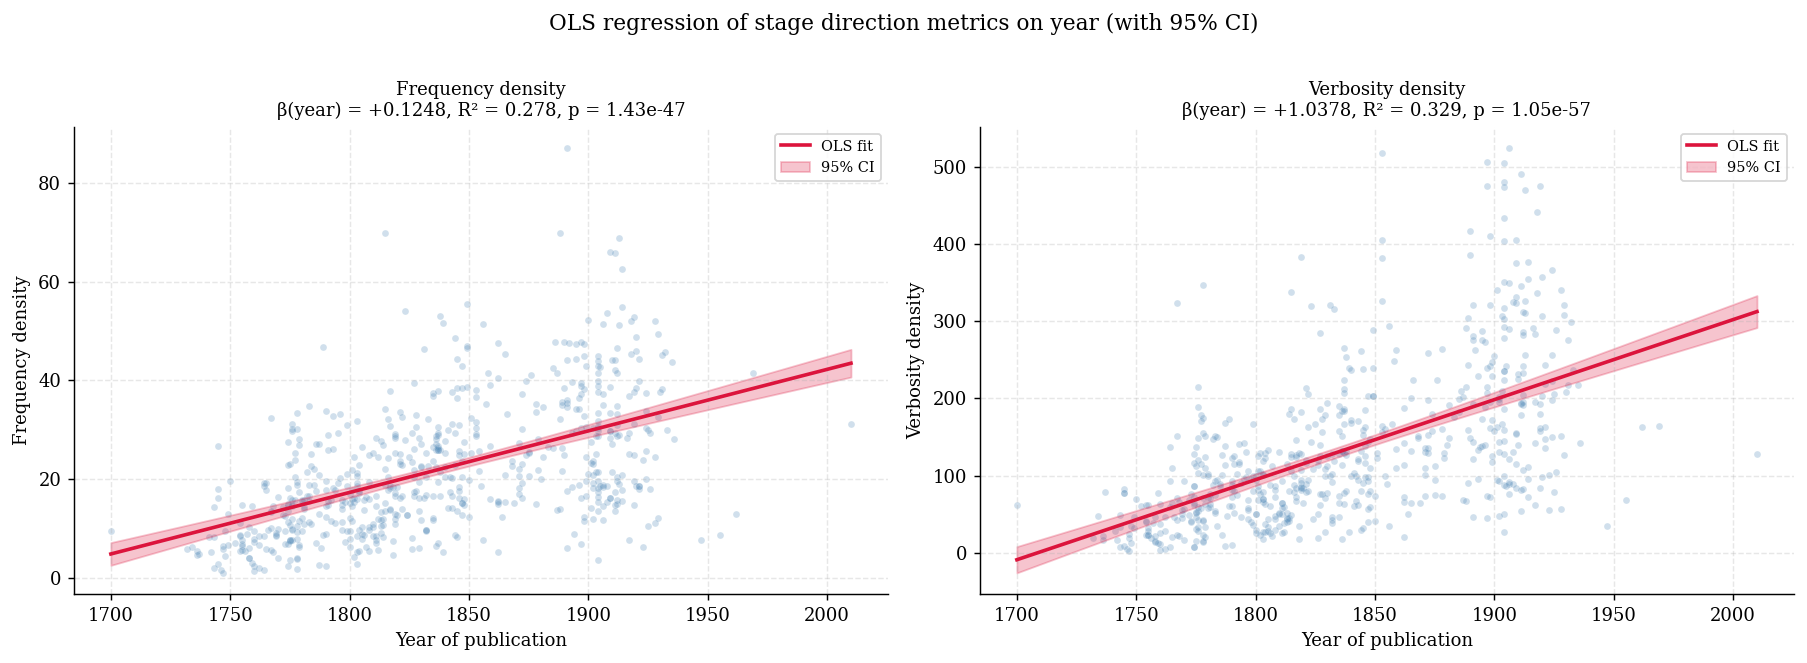

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes,
    ['stage_per_1k_words', 'stage_words_per_1k'],
    ['Frequency density', 'Verbosity density']):

    model = smf.ols(f'{col} ~ year', data=df).fit()
    x_pred = np.linspace(df['year'].min(), df['year'].max(), 300)
    pred = model.get_prediction(pd.DataFrame({'year': x_pred}))
    pred_df = pred.summary_frame(alpha=0.05)

    ax.scatter(df['year'], df[col], alpha=0.25, s=14, color='steelblue', linewidths=0)
    ax.plot(x_pred, pred_df['mean'], color='crimson', linewidth=2, label='OLS fit')
    ax.fill_between(x_pred, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                    alpha=0.25, color='crimson', label='95% CI')

    r2 = model.rsquared
    beta = model.params['year']
    pval = model.pvalues['year']
    ax.set_title(f'{label}\nβ(year) = {beta:+.4f}, R² = {r2:.3f}, p = {pval:.2e}', fontsize=10)
    ax.set_xlabel('Year of publication')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)

plt.suptitle('OLS regression of stage direction metrics on year (with 95% CI)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Period-level Summary Table

In [17]:
summary = df.groupby('period', observed=True).agg(
    n_plays                = ('filename',           'count'),
    median_text_words      = ('word_count_l_p',      'median'),
    median_stage_count     = ('stage_count',          'median'),
    median_avg_words       = ('stage_avg_words',      'median'),
    median_freq_density    = ('stage_per_1k_words',   'median'),
    median_verbosity       = ('stage_words_per_1k',   'median'),
).round(2)

summary.columns = ['N plays', 'Median text words', 'Median stage count',
                   'Median avg words/dir.', 'Median freq/1k', 'Median verbosity/1k']
print(summary.to_string())

           N plays  Median text words  Median stage count  Median avg words/dir.  Median freq/1k  Median verbosity/1k
period                                                                                                               
1700–1750       24            16239.0               100.0                   3.58            6.26                30.21
1751–1800      167            11703.0               141.0                   4.80           12.92                63.00
1801–1850      210            13933.5               237.0                   5.05           18.93                99.06
1851–1900      111            14797.0               365.0                   5.71           29.20               159.73
1901+          134            11434.5               321.5                   6.84           28.70               198.70


## 8. Interpretation & Discussion

### What the data show

**Stage direction frequency increases significantly over time.**  
The Spearman correlation between year and frequency density (`stage_per_1k_words`) is moderate and highly significant (ρ ≈ 0.58, p < .001), and the OLS β(year) is positive, meaning every decade adds roughly a quantifiable number of additional stage directions per 1,000 text words. The Kruskal-Wallis test confirms that the five half-century periods differ significantly (p < .001), and post-hoc tests reveal that the sharpest breaks occur between the 18th-century periods and the post-1850 corpus.

**Stage direction verbosity increases even more strongly over time.**  
The correlation of year with verbosity density (`stage_words_per_1k`) is stronger still (ρ ≈ 0.65, p < .001), indicating that not only do stage directions become more frequent, they also become considerably longer. The median verbosity density grows roughly sevenfold from the 1700–1750 period to the post-1900 period, pointing to a fundamental shift in dramatic writing practice from terse blocking cues toward elaborate descriptive prose.

**Pure text length is essentially independent of publication year.**  
The correlation between year and text word count is weak and non-significant (ρ ≈ −0.04, p ≈ .30), meaning the growing space devoted to stage directions is not simply a byproduct of longer plays — it reflects an autonomous increase in paratextual material.

**Text length is not a meaningful predictor of stage direction frequency.**  
The correlation between `word_count_l_p` and `stage_per_1k_words` is near zero and marginally non-significant (ρ ≈ −0.07, p ≈ .06). The normalisation by 1,000 words successfully removes the confounding effect of play length, and the multiple regression confirms that year remains the dominant predictor even when text length is controlled for.

### Implications
These findings are consistent with the broader literary-historical narrative of the 19th century as the period in which stage directions evolved from minimal functional cues into a literary genre in their own right — a trend associated with Naturalism, the rise of the stage director, and increased readership of printed drama rather than purely performed drama.